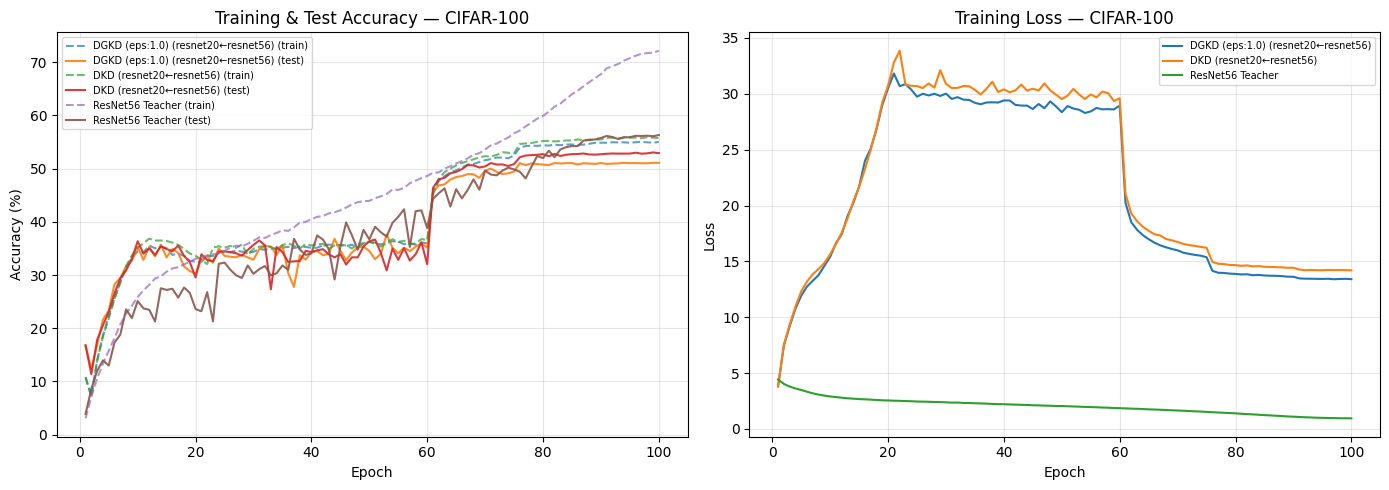

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import os

log_dir = "logs-results/CIFAR-100"

files = {
    "DGKD (eps:1.0) (resnet20←resnet56)": "decoupled_gradient_distillation_resnet20_resnet56_CIFAR-100.csv",
    "DKD (resnet20←resnet56)":     "decoupled_resnet20_resnet56_CIFAR-100.csv",
    "ResNet56 Teacher":            "resnet56_CIFAR-100.csv",
}

dfs = {label: pd.read_csv(os.path.join(log_dir, fname)) for label, fname in files.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for label, df in dfs.items():
    ax1.plot(df["epochs"], df["train_acc"], linestyle="--", alpha=0.7, label=f"{label} (train)")
    ax1.plot(df["epochs"], df["test_acc"],  linestyle="-",  alpha=0.9, label=f"{label} (test)")

ax1.set_title("Training & Test Accuracy — CIFAR-100")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.legend(fontsize=7)
ax1.grid(True, alpha=0.3)

for label, df in dfs.items():
    ax2.plot(df["epochs"], df["train_loss"], label=label)

ax2.set_title("Training Loss — CIFAR-100")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend(fontsize=7)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# save the graph has pdf. 
fig.savefig("cifar100_training_comparison.jpeg")
